In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Everything works!")

Everything works!


In [3]:
import os

print(os.listdir("../data"))


['Sample - Superstore.csv']


In [4]:
import pandas as pd

df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

print(df.shape)
df.head()
df.info()

(9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df[['Order Date','Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [6]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [7]:
sales_df = df.groupby('Order Date')['Sales'].sum().reset_index()

sales_df.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


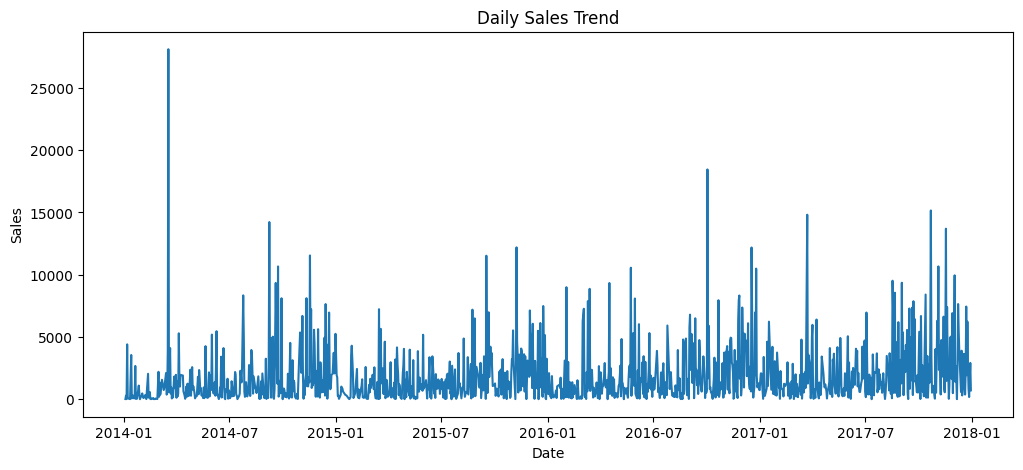

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    sales_df['Order Date'],
    sales_df['Sales']
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

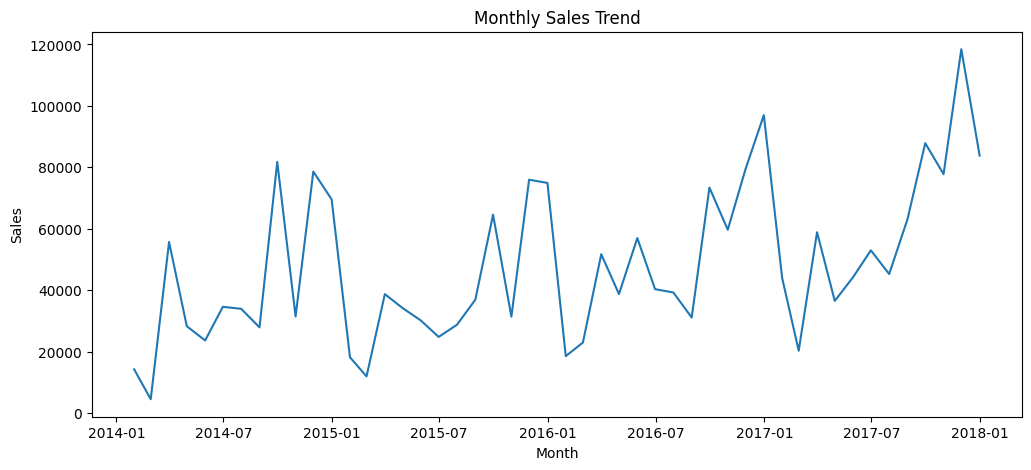

In [9]:
monthly_sales = sales_df.resample(
    'ME',
    on='Order Date'
).sum()

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales['Sales']
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [10]:
sales_df.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [11]:
sales_df['year'] = sales_df['Order Date'].dt.year
sales_df['month'] = sales_df['Order Date'].dt.month
sales_df['day'] = sales_df['Order Date'].dt.day
sales_df['dayofweek'] = sales_df['Order Date'].dt.dayofweek
sales_df['quarter'] = sales_df['Order Date'].dt.quarter

sales_df.head()

,Order Date,Sales,year,month,day,dayofweek,quarter
0,2014-01-03,16.448,2014,1,3,4,1
1,2014-01-04,288.060,2014,1,4,5,1
2,2014-01-05,19.536,2014,1,5,6,1
3,2014-01-06,4407.100,2014,1,6,0,1
4,2014-01-07,87.158,2014,1,7,1,1


In [12]:
X = sales_df[
    ['year',
     'month',
     'day',
     'dayofweek',
     'quarter']
]

y = sales_df['Sales']

In [13]:
X.head()

,year,month,day,dayofweek,quarter
0,2014,1,3,4,1
1,2014,1,4,5,1
2,2014,1,5,6,1
3,2014,1,6,0,1
4,2014,1,7,1,1


In [14]:
y.head()

0      16.448
1     288.060
2      19.536
3    4407.100
4      87.158
Name: Sales, dtype: float64

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(989, 5)
(248, 5)
(989,)
(248,)


In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [18]:
pred = model.predict(X_test)

pred[:10]

array([ 975.32971 , 1776.94117 , 2146.96233 , 2557.75696 , 1582.09682 ,
       1456.20009 , 1222.36189 ,  873.20591 , 2155.546595, 2282.849095])

In [19]:
print(X_train.shape)
print(X_test.shape)

pred[:10]

(989, 5)
(248, 5)


array([ 975.32971 , 1776.94117 , 2146.96233 , 2557.75696 , 1582.09682 ,
       1456.20009 , 1222.36189 ,  873.20591 , 2155.546595, 2282.849095])

In [20]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)

print("MAE:", mae)

MAE: 1799.8410292177423


In [21]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("RMSE:", rmse)

RMSE: 2531.337842895988


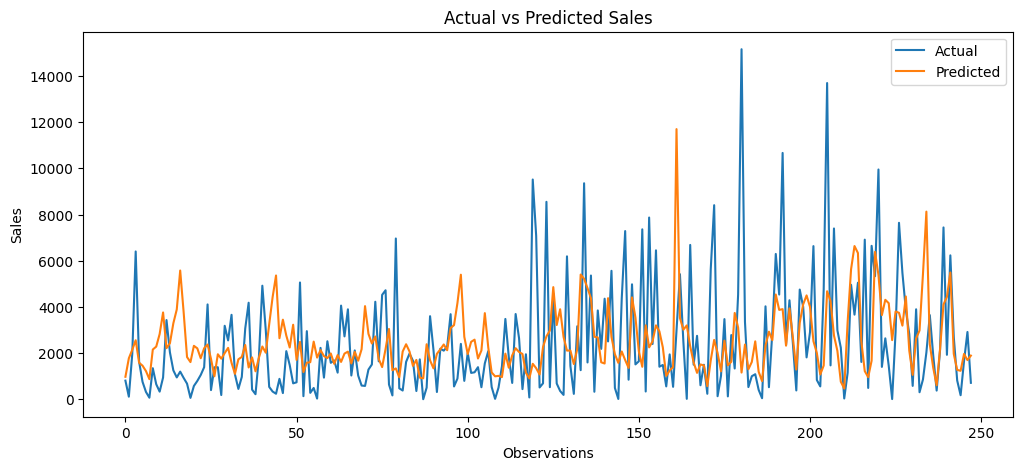

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Observations")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [23]:
future_dates = pd.date_range(
    start=sales_df['Order Date'].max() + pd.Timedelta(days=1),
    periods=30
)

future_dates

DatetimeIndex(['2017-12-31', '2018-01-01', '2018-01-02', '2018-01-03',
               '2018-01-04', '2018-01-05', '2018-01-06', '2018-01-07',
               '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11',
               '2018-01-12', '2018-01-13', '2018-01-14', '2018-01-15',
               '2018-01-16', '2018-01-17', '2018-01-18', '2018-01-19',
               '2018-01-20', '2018-01-21', '2018-01-22', '2018-01-23',
               '2018-01-24', '2018-01-25', '2018-01-26', '2018-01-27',
               '2018-01-28', '2018-01-29'],
              dtype='datetime64[us]', freq='D')

In [24]:
future_df = pd.DataFrame()

future_df['year'] = future_dates.year
future_df['month'] = future_dates.month
future_df['day'] = future_dates.day
future_df['dayofweek'] = future_dates.dayofweek
future_df['quarter'] = future_dates.quarter

future_df.head()

,year,month,day,dayofweek,quarter
0,2017,12,31,6,4
1,2018,1,1,0,1
2,2018,1,2,1,1
3,2018,1,3,2,1
4,2018,1,4,3,1


In [25]:
future_sales = model.predict(future_df)

future_sales[:10]

array([3238.45963, 2030.62154, 3809.48633, 1700.70894, 1148.88766,
       1004.37484, 1633.89376, 1996.53824, 1459.72198, 1010.06099])

In [26]:
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted Sales': future_sales
})

forecast_df.head()

,Date,Forecasted Sales
0,2017-12-31,3238.45963
1,2018-01-01,2030.62154
2,2018-01-02,3809.48633
3,2018-01-03,1700.70894
4,2018-01-04,1148.88766


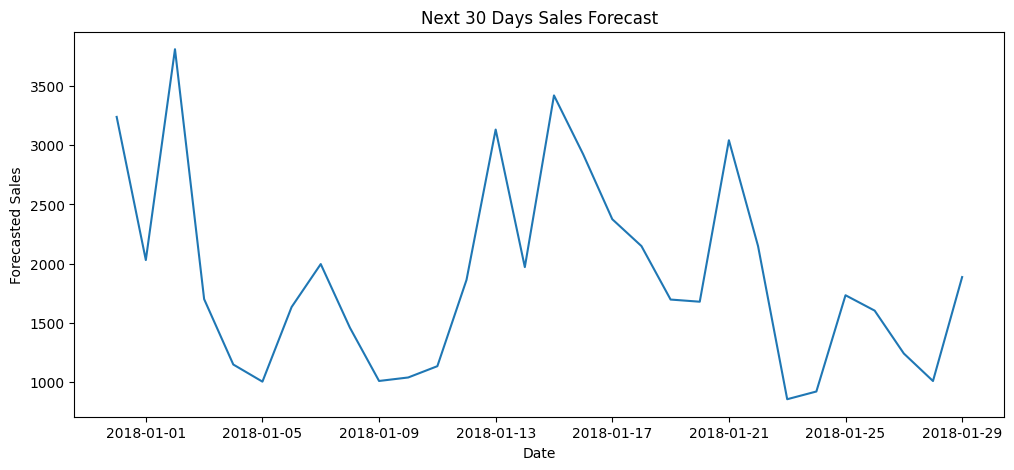

In [27]:
plt.figure(figsize=(12,5))

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecasted Sales']
)

plt.title("Next 30 Days Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")

plt.show()

In [30]:
sales_df['lag_1'] = sales_df['Sales'].shift(1)

sales_df['lag_7'] = sales_df['Sales'].shift(7)

sales_df['rolling_mean_7'] = (
    sales_df['Sales']
    .rolling(window=7)
    .mean()
)

In [31]:
sales_df.dropna(inplace=True)

In [34]:
X = sales_df[
    [
        'year',
        'month',
        'day',
        'dayofweek',
        'quarter',
        'lag_1',
        'lag_7',
        'rolling_mean_7'
    ]
]

y = sales_df['Sales']
X.head()

,year,month,day,dayofweek,quarter,lag_1,lag_7,rolling_mean_7
7,2014,1,11,5,1,54.830,16.448,701.024000
8,2014,1,13,0,1,9.940,288.060,1167.557571
9,2014,1,14,1,1,3553.795,19.536,1173.618143
10,2014,1,15,2,1,61.960,4407.100,565.453857
11,2014,1,16,3,1,149.950,87.158,595.854714


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [36]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [37]:
pred = model.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)

print("New MAE:", mae)

New MAE: 1748.981259695122


In [39]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("New RMSE:", rmse)

New RMSE: 2337.726441453335


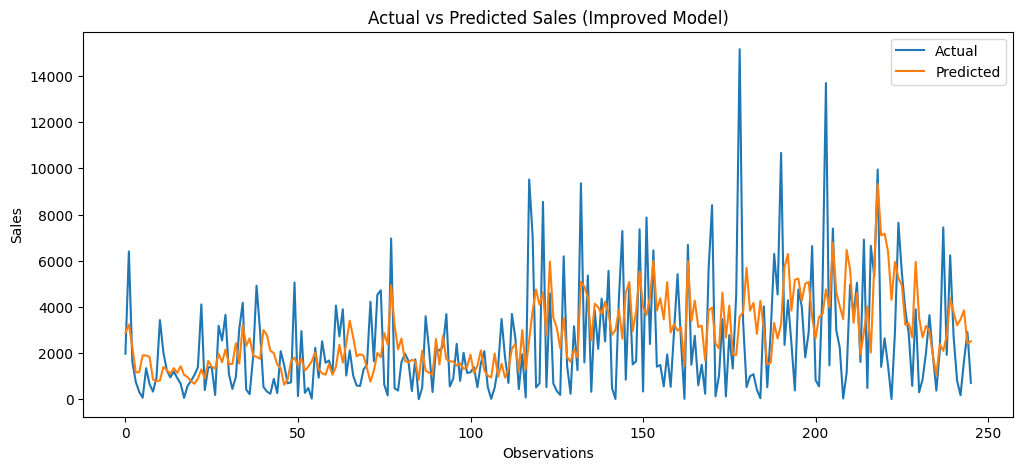

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")

plt.title("Actual vs Predicted Sales (Improved Model)")
plt.xlabel("Observations")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [41]:
future_dates = pd.date_range(
    start=sales_df['Order Date'].max() + pd.Timedelta(days=1),
    periods=30
)

print(future_dates[:5])

DatetimeIndex(['2017-12-31', '2018-01-01', '2018-01-02', '2018-01-03',
               '2018-01-04'],
              dtype='datetime64[us]', freq='D')


In [43]:
future_df = pd.DataFrame()

future_df['year'] = future_dates.year
future_df['month'] = future_dates.month
future_df['day'] = future_dates.day
future_df['dayofweek'] = future_dates.dayofweek
future_df['quarter'] = future_dates.quarter
future_df.head()

,year,month,day,dayofweek,quarter
0,2017,12,31,6,4
1,2018,1,1,0,1
2,2018,1,2,1,1
3,2018,1,3,2,1
4,2018,1,4,3,1


In [44]:
history = sales_df.copy()

history.tail()

,Order Date,Sales,year,month,day,dayofweek,quarter,lag_1,lag_7,rolling_mean_7
1232,2017-12-26,814.5940,2017,12,26,1,4,2698.9270,1895.926,3090.578286
1233,2017-12-27,177.6360,2017,12,27,2,4,814.5940,377.736,3061.992571
1234,2017-12-28,1657.3508,2017,12,28,3,4,177.6360,2140.940,2992.908400
1235,2017-12-29,2915.5340,2017,12,29,4,4,1657.3508,7442.021,2346.267400
1236,2017-12-30,713.7900,2017,12,30,5,4,2915.5340,1926.776,2172.983686


In [45]:
future_dates = pd.date_range(
    start=sales_df['Order Date'].max() + pd.Timedelta(days=1),
    periods=30
)
future_dates[:5]

DatetimeIndex(['2017-12-31', '2018-01-01', '2018-01-02', '2018-01-03',
               '2018-01-04'],
              dtype='datetime64[us]', freq='D')

In [46]:
future_predictions = []

In [47]:
for date in future_dates:

    year = date.year
    month = date.month
    day = date.day
    dayofweek = date.dayofweek
    quarter = date.quarter

    lag_1 = history['Sales'].iloc[-1]

    lag_7 = history['Sales'].iloc[-7]

    rolling_mean_7 = history['Sales'].tail(7).mean()

    X_future = pd.DataFrame({
        'year': [year],
        'month': [month],
        'day': [day],
        'dayofweek': [dayofweek],
        'quarter': [quarter],
        'lag_1': [lag_1],
        'lag_7': [lag_7],
        'rolling_mean_7': [rolling_mean_7]
    })

    prediction = model.predict(X_future)[0]

    future_predictions.append(prediction)

    history = pd.concat([
        history,
        pd.DataFrame({
            'Order Date': [date],
            'Sales': [prediction]
        })
    ], ignore_index=True)

In [48]:
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted Sales': future_predictions
})

forecast_df.head()

,Date,Forecasted Sales
0,2017-12-31,3483.949451
1,2018-01-01,1786.299740
2,2018-01-02,1270.385530
3,2018-01-03,765.778560
4,2018-01-04,1510.513310


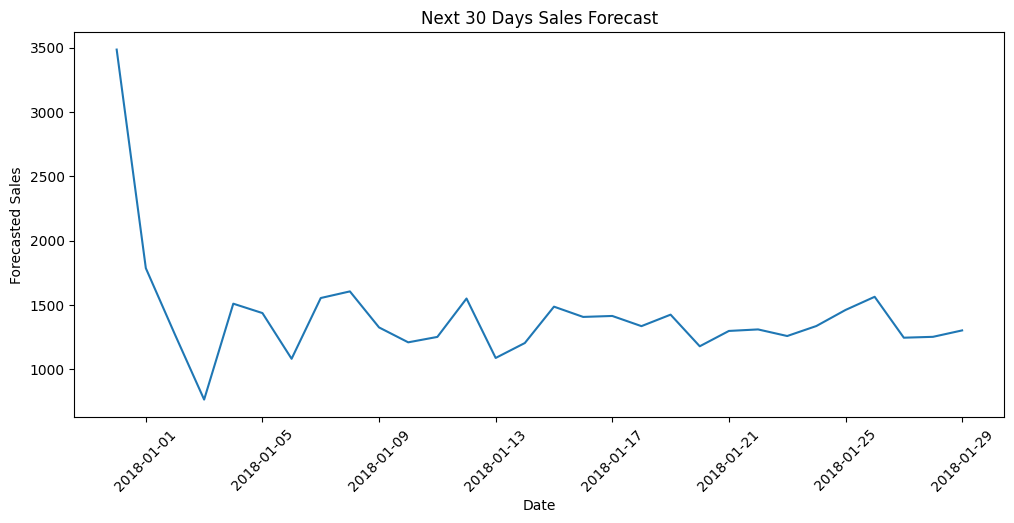

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecasted Sales']
)

plt.title("Next 30 Days Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")

plt.xticks(rotation=45)

plt.show()

In [50]:
forecast_df.to_csv(
    "../report/30_day_forecast.csv",
    index=False
)